In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from create_system_matrix import load_H_matrix, create_system_matrices

from scipy.linalg import eig
from matplotlib.scale import SymmetricalLogTransform


In [37]:
#%% PLOT SETTINGS
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'grid.alpha': 0.3,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.dpi': 150,
    'axes.facecolor': '#F1F5F2',
    'axes.grid': True
})

colors = plt.get_cmap('tab10').colors
#turn colors into a list
colors = [colors[i] for i in range(len(colors))]
colors = ['#EFA00B', '#439775', '#4B4E6D', '#6A4C93', '#FAC8CD', '#9BC1BC', '#5D737E', '#D9BF77', '#ACD8AA', '#FFE156']

## **Standard Bat**

In [60]:
H_alan = load_H_matrix('data/H_matrix_Alan.csv')

In [61]:
# edge case ij, ji, all of jj
# 
mass = 0.885 # in kg
rho = 649 # in kg/m^3

Y = 1.814 * 1e10  # convert to N/m^2
S = 1.05 * 1e9 # convert to N/m^2
N = 84  # number of slices
dz = 0.84 / N # slice thickness in m

# load bat profile
bat_prof = np.loadtxt('data/r161.dat')
bat_prof[:, 1] = bat_prof[:, 1] / 2 # convert diameter to radius
Ai = np.pi * (bat_prof[:, 1] * 1e-3)**2  # in m^2
Vi = Ai * dz  # in m^3
Ii = np.pi/4 * (bat_prof[:, 1] * 1e-3)**4  # in m^4

Lam = S / (rho * dz**2)
Ups = Y / (rho * dz**2)
H_nava = create_system_matrices(N, Ai, Ii, dz, S, Y, rho)

In [62]:
#eigenvals nava
evalsA, evecsA = np.linalg.eig(H_nava)
omegaA = np.sqrt(np.abs(evalsA))
freqsA = omegaA / (2 * np.pi)
freqsA.sort()
print(freqsA[:10])

[5.32862558e-04 3.54037301e+02 3.54037301e+02 1.01553636e+03
 1.69146862e+03 2.43278135e+03 3.10863454e+03 3.43901123e+03
 4.10772966e+03 4.90179210e+03]


### **Find Largest Disrepencies**

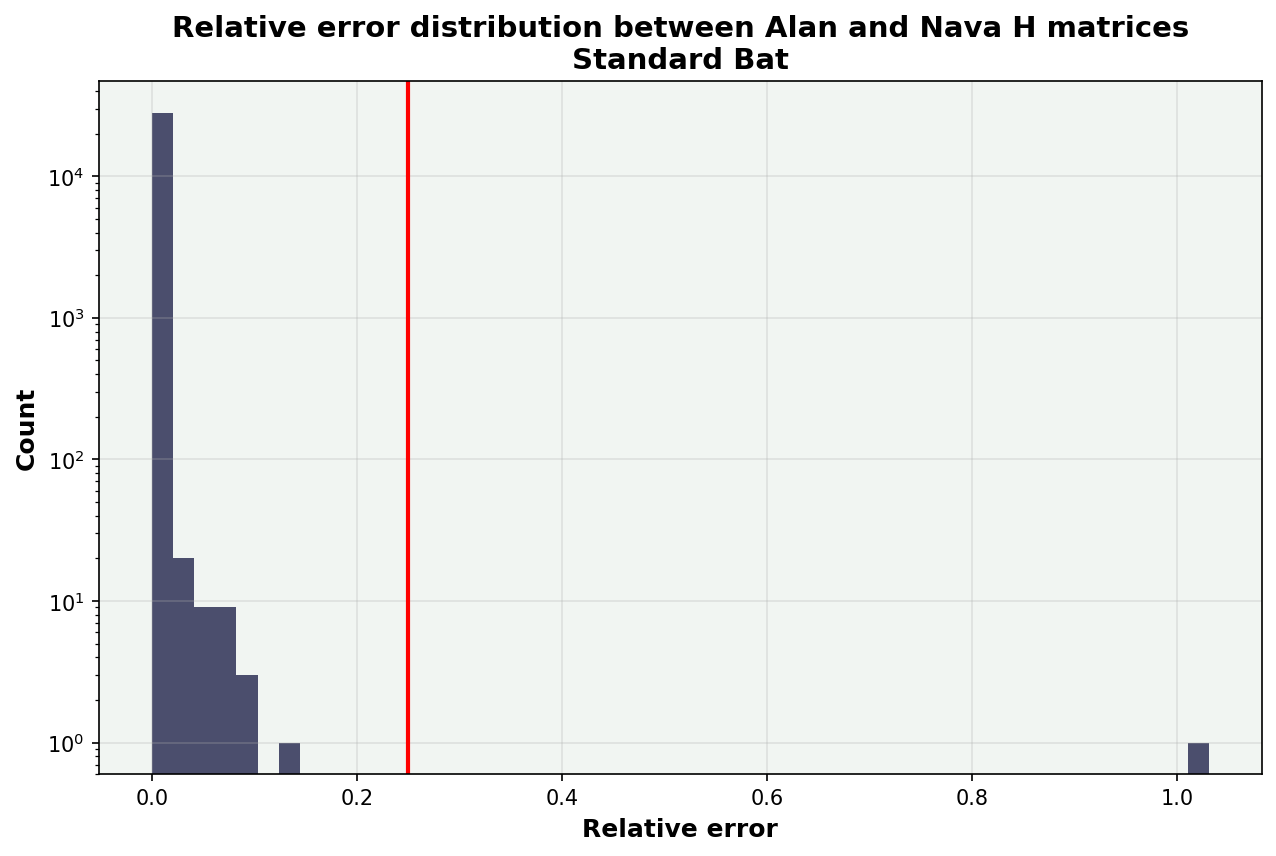

In [63]:
#rel error
rel_error = np.abs(H_alan - H_nava) / (np.abs(H_alan) + 1e-10)
#histogram
plt.hist(rel_error.flatten(), bins = 50, color = colors[2])
plt.xlabel('Relative error')
plt.axvline(x = 0.25, color = 'red', label = '0.25 threshold')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Relative error distribution between Alan and Nava H matrices\nStandard Bat')
plt.show()

In [64]:
# high error
high_error_idxs = np.where(rel_error > 0.25)
discrepancy_df = pd.DataFrame({
    'Row': high_error_idxs[0] + 1,  # add 1 to convert from 0-indexed to 1-indexed
    'Col': high_error_idxs[1] + 1,  # add 1 to convert from 0-indexed to 1-indexed
    'Quandrant': np.where((high_error_idxs[0] < N) & (high_error_idxs[1] < N), '1',
                 np.where((high_error_idxs[0] < N) & (high_error_idxs[1] >= N), '2',
                 np.where((high_error_idxs[0] >= N) & (high_error_idxs[1] < N), '3', '4'))),
    'Alan Value': H_alan[high_error_idxs],
    'Nava Value': H_nava[high_error_idxs],
    'Relative Error': rel_error[high_error_idxs]
})
discrepancy_df

,Row,Col,Quandrant,Alan Value,Nava Value,Relative Error
0,86,3,3,-5.075200e+09,-1.030731e+10,1.030916


In [ ]:
i = 

2

In [43]:
mass = 0.885 # in kg
rho = 649 # in kg/m^3

Y = 1.814 * 1e10  # convert to N/m^2
S = 1.05 * 1e9 # convert to N/m^2
N = 84  # number of slices
dz = 0.84 / N # slice thickness in m

# load bat profile
bat_prof = np.loadtxt('data/r161.dat')
bat_prof[:, 1] = bat_prof[:, 1] / 2 # convert diameter to radius
Ai = np.pi * (bat_prof[:, 1] * 1e-3)**2  # in m^2
Vi = Ai * dz  # in m^3
Ii = np.pi/4 * (bat_prof[:, 1] * 1e-3)**4  # in m^4

Lam = S / (rho * dz**2)
Ups = Y / (rho * dz**2)
H_nava = create_system_matrices(N, Ai, Ii, dz, S, Y, rho)

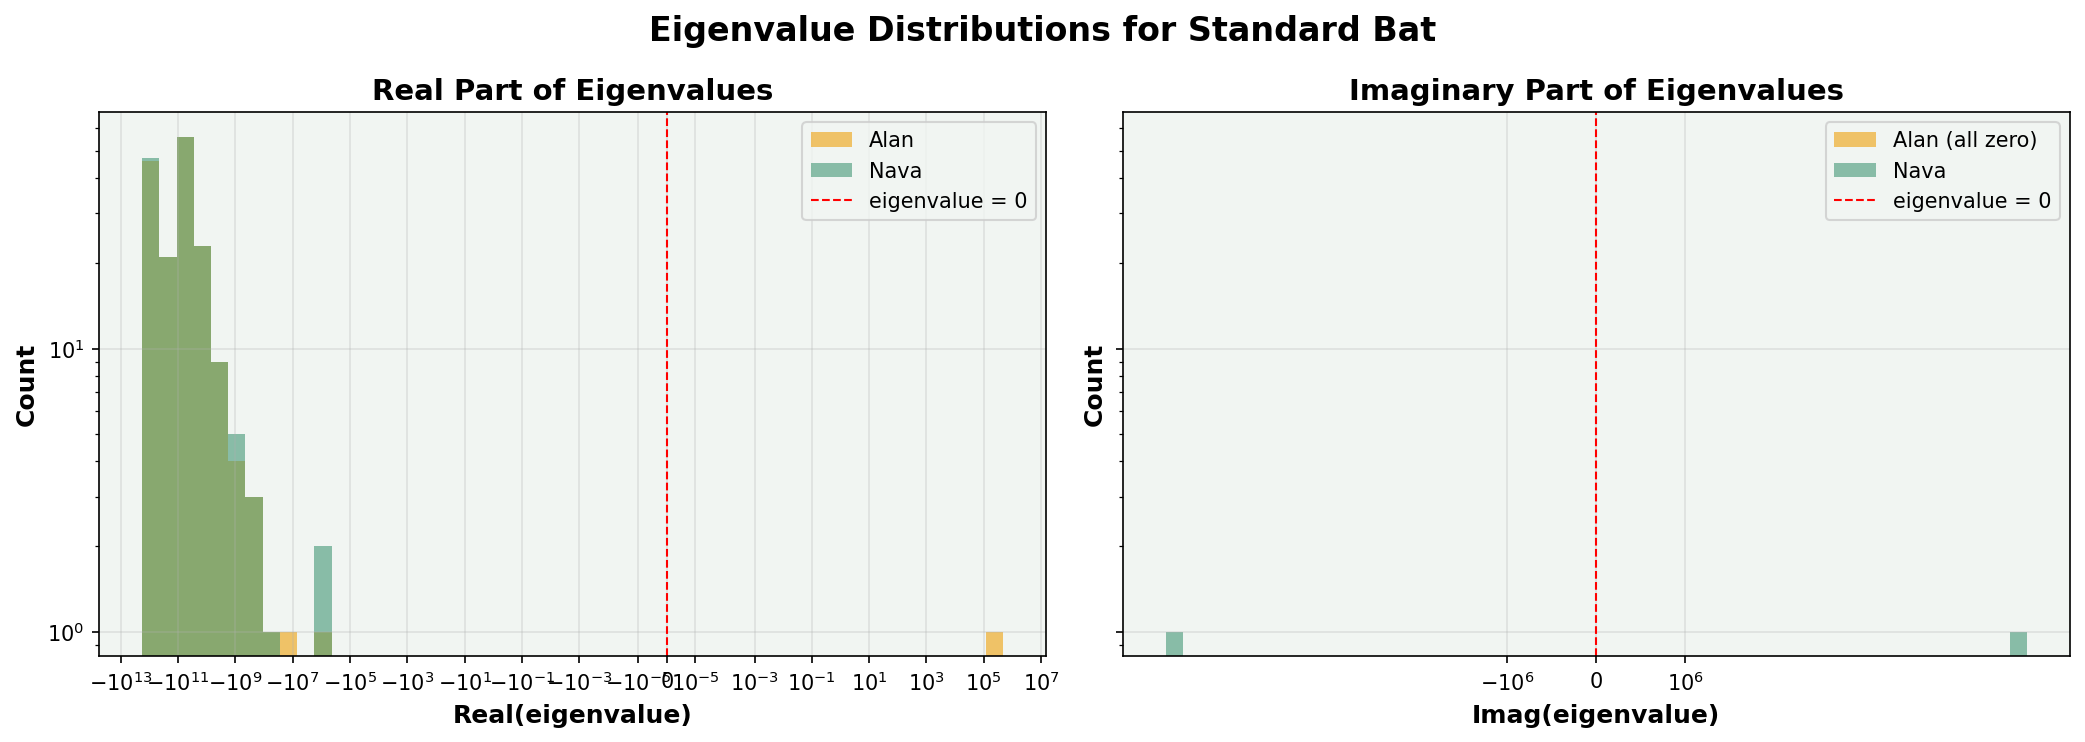

In [44]:

# Compute eigenvalues for both matrices
evals_alan = np.linalg.eig(H_alan)[0]
evals_nava = np.linalg.eig(H_nava)[0]

def symlog_bins(data_list, nbins=50, linthresh=1.0):
    """Create bins that are evenly spaced in symlog-transformed coordinates."""
    all_data = np.concatenate(data_list)
    fwd = SymmetricalLogTransform(base=10, linthresh=linthresh, linscale=1)
    inv = fwd.inverted()
    transformed = fwd.transform_non_affine(all_data)
    t_bins = np.linspace(transformed.min(), transformed.max(), nbins + 1)
    return inv.transform_non_affine(t_bins)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey = True)

# --- Real part histogram ---
real_alan = evals_alan.real
real_nava = evals_nava.real
real_alan_nz = real_alan[real_alan != 0]
real_nava_nz = real_nava[real_nava != 0]

all_real = np.concatenate([real_alan_nz, real_nava_nz])
r_linthresh = np.min(np.abs(all_real[all_real != 0]))
rbins = symlog_bins([real_alan_nz, real_nava_nz], nbins=50, linthresh=r_linthresh)

axes[0].hist(real_alan_nz, bins=rbins, alpha=0.6, label='Alan', color = colors[0])
axes[0].hist(real_nava_nz, bins=rbins, alpha=0.6, label='Nava', color = colors[1])
axes[0].set_xscale('symlog', linthresh=r_linthresh)
axes[0].set_yscale('log')
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=1, label='eigenvalue = 0')
axes[0].set_xlabel('Real(eigenvalue)')
axes[0].set_ylabel('Count')
axes[0].set_title('Real Part of Eigenvalues')
axes[0].legend()

# --- Imaginary part histogram ---
imag_alan = evals_alan.imag
imag_nava = evals_nava.imag
imag_alan_nz = imag_alan[imag_alan != 0]
imag_nava_nz = imag_nava[imag_nava != 0]

imag_all_nz = np.concatenate([imag_alan_nz, imag_nava_nz])
if len(imag_all_nz) > 0:
    i_linthresh = np.min(np.abs(imag_all_nz[imag_all_nz != 0]))
    ibins = symlog_bins([imag_all_nz], nbins=50, linthresh=i_linthresh)

    if len(imag_alan_nz) > 0:
        axes[1].hist(imag_alan_nz, bins=ibins, alpha=0.6, label='Alan', color = colors[0])
    else:
        axes[1].hist([], label='Alan (all zero)', color = colors[0], alpha = 0.6)
    if len(imag_nava_nz) > 0:
        axes[1].hist(imag_nava_nz, bins=ibins, alpha=0.6, label='Nava', color = colors[1])
    else:
        axes[1].plot([], [], ' ', label='Nava (all zero)', color = colors[1])

    axes[1].set_xscale('symlog', linthresh=i_linthresh)
    axes[1].set_yscale('log')
    axes[1].axvline(x=0, color='r', linestyle='--', linewidth=1, label='eigenvalue = 0')
    axes[1].set_xlabel('Imag(eigenvalue)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Imaginary Part of Eigenvalues')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'All imaginary parts are zero',
                 transform=axes[1].transAxes, ha='center', va='center')
    axes[1].set_title('Imaginary Part of Eigenvalues')
plt.suptitle('Eigenvalue Distributions for Standard Bat', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## **Solid Cylinder**

In [45]:
N = 86 
dz= 0.01
L=33.86 # convert to m
L = L * 0.0254 # convert to m

M=62.3 #oz
M = 62.3 * 0.0283495 # convert to kg


Y=0.181e11 #N/m^2
S=0.105e10 #N/m^2
rho=649 #kg/m^3
D = 2.5 * 0.0254 # convert to m
Ris = D / 2 * np.ones(N)

Iis = np.pi/4 * (Ris)**4
H_solid = create_system_matrices(N, Ai=np.pi*Ris**2, Ii=Iis, dz=dz, S=S, Y=Y, rho=rho)

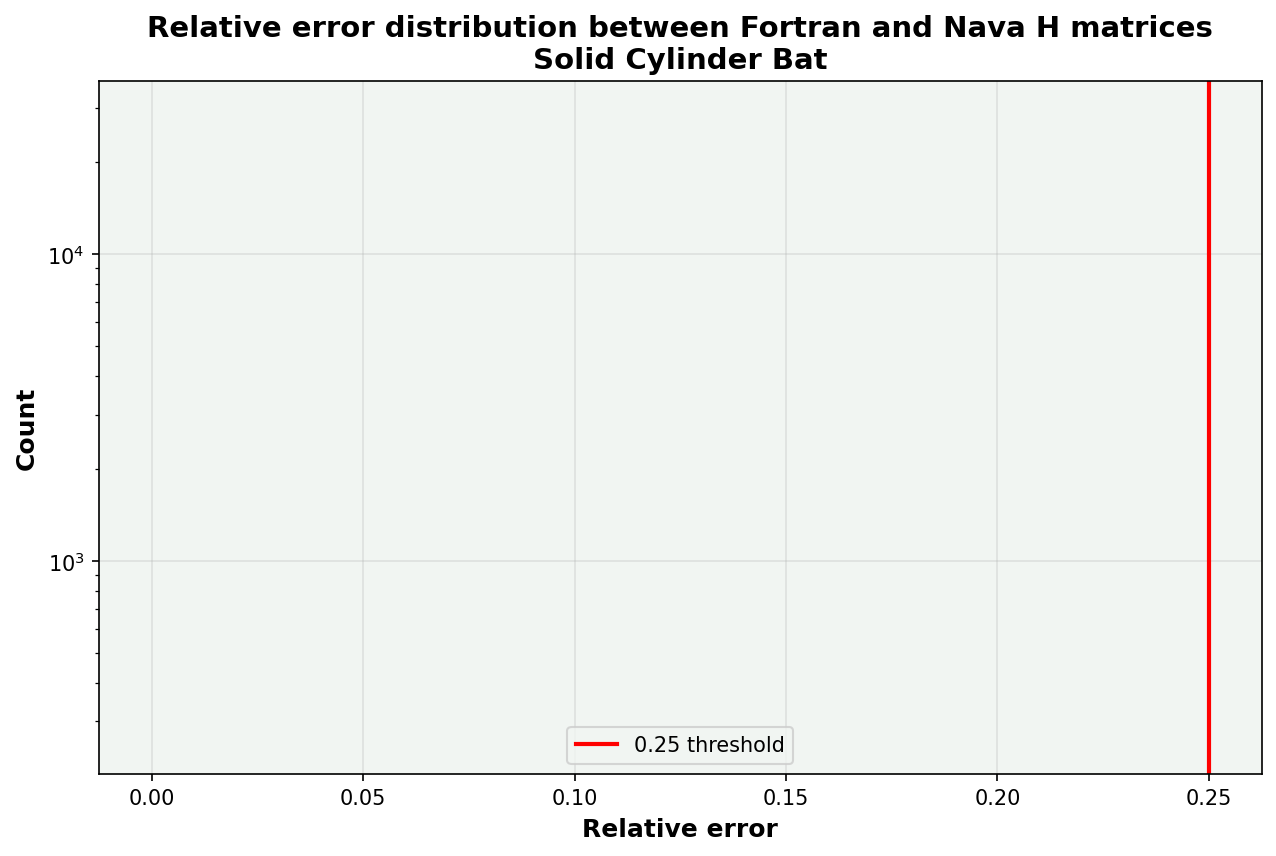

In [46]:
# Read the sparse triplet format
data = np.loadtxt('fort.200')
rows = data[:, 0].astype(int) - 1  # convert to 0-indexed
cols = data[:, 1].astype(int) - 1
vals = data[:, 2]

# Build dense matrix
N_total = int(max(rows.max(), cols.max())) + 1  # 172
H_fortran = np.zeros((N_total, N_total))
H_fortran[rows, cols] = vals

#compare H_fortran and H_solid
rel_error_cyl = np.abs(H_fortran - H_solid) / (np.abs(H_fortran) + 1e-15)
plt.hist(rel_error_cyl.flatten(), bins = 50, color = colors[3])
plt.xlabel('Relative error')
plt.axvline(x = 0.25, color = 'red', label = '0.25 threshold')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Relative error distribution between Fortran and Nava H matrices\nSolid Cylinder Bat')
plt.legend()
plt.show()

In [47]:
# high error
high_error_idxs = np.where(rel_error_cyl > 0.25)
discrepancy_df = pd.DataFrame({
    'Row': high_error_idxs[0] + 1,  # add 1 to convert from 0-indexed to 1-indexed
    'Col': high_error_idxs[1] + 1,  # add 1 to convert from 0-indexed to 1-indexed
    'Quandrant': np.where((high_error_idxs[0] < N) & (high_error_idxs[1] < N), '1',
                 np.where((high_error_idxs[0] < N) & (high_error_idxs[1] >= N), '2',
                 np.where((high_error_idxs[0] >= N) & (high_error_idxs[1] < N), '3', '4'))),
    'Alan Value': H_fortran[high_error_idxs],
    'Nava Value': H_solid[high_error_idxs],
    'Relative Error': rel_error_cyl[high_error_idxs]
})
discrepancy_df

,Row,Col,Quandrant,Alan Value,Nava Value,Relative Error


In [48]:
evals_solid = np.linalg.eig(H_solid)[0]
omega_solid = np.sqrt(np.abs(evals_solid))
freqs_solid = omega_solid / (2 * np.pi)
freqs_solid.sort()
print(freqs_solid[:10])
alan_f = [387,
976,
1711,
2509,
3328,
4147,
]
print(alan_f)

[7.14008879e-04 1.02744694e-03 3.87033324e+02 9.75158900e+02
 1.71034837e+03 2.50807665e+03 3.32658745e+03 4.14576633e+03
 4.95754761e+03 5.75888769e+03]
[387, 976, 1711, 2509, 3328, 4147]


## **Torpedo**

Now Compare for Torpedo

In [49]:
N = 85

Y = 1.65 * 1e10  # convert to N/m^2
S = 0.9 * 1e9 # convert to N/m^2
dz = 0.85 / N # slice thickness in m
rho = 690 #in kg/m

# load bat profile
bat_prof = np.loadtxt('data/torpedo.dat')
bat_prof[:, 1] = bat_prof[:, 1] / 2 # convert diameter to radius
Ai = np.pi * (bat_prof[:, 1] * 1e-3)**2  # in m^2
Vi = Ai * dz  # in m^3
Ii = np.pi/4 * (bat_prof[:, 1] * 1e-3)**4  # in m^4

Lam = S / (rho * dz**2)
Ups = Y / (rho * dz**2)

H_navaT = create_system_matrices(N, Ai, Ii, dz, S, Y, rho)
H_alanT = load_H_matrix('data/H_matrix_torpedo.csv', N)

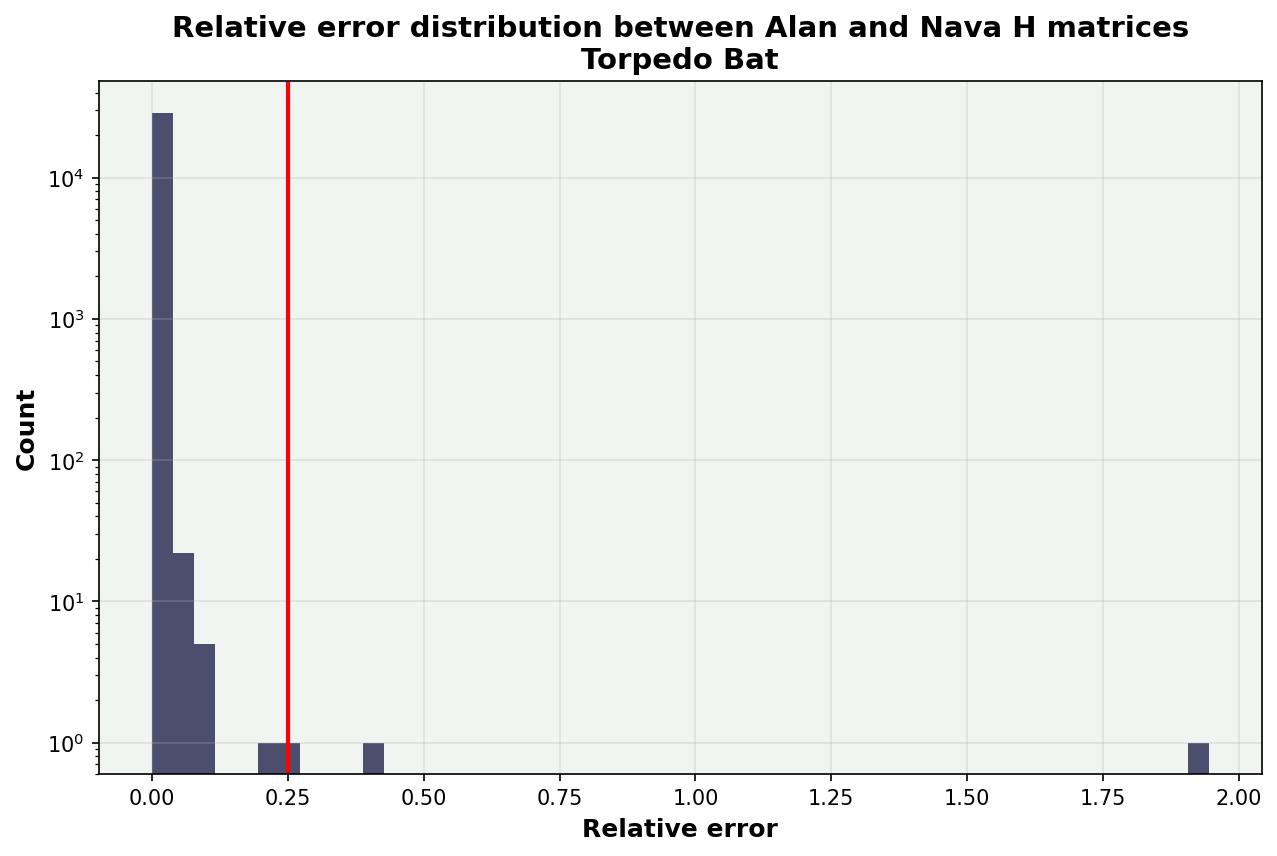

In [50]:
#rel error
rel_error = np.abs(H_alanT - H_navaT) / (np.abs(H_alanT) + 1e-10)
plt.hist(rel_error.flatten(), bins = 50, color = colors[2])
plt.xlabel('Relative error')
plt.axvline(x = 0.25, color = 'red', label = '0.25 threshold')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Relative error distribution between Alan and Nava H matrices\nTorpedo Bat')
plt.show()

In [51]:
# high error
high_error_idxs = np.where(rel_error > 0.25)
discrepancy_dfT = pd.DataFrame({
    'Row': high_error_idxs[0] + 1,  # add 1 to convert from 0-indexed to 1-indexed
    'Col': high_error_idxs[1] + 1,  # add 1 to convert from 0-indexed to 1-indexed
    'Quadrant': np.where((high_error_idxs[0] < N) & (high_error_idxs[1] < N), '1',
                 np.where((high_error_idxs[0] < N) & (high_error_idxs[1] >= N), '2',
                 np.where((high_error_idxs[0] >= N) & (high_error_idxs[1] < N), '3', '4'))),
    'Alan Value': H_alanT[high_error_idxs],
    'Nava Value': H_navaT[high_error_idxs],
    'Relative Error': rel_error[high_error_idxs]
})
discrepancy_dfT

,Row,Col,Quadrant,Alan Value,Nava Value,Relative Error
0,87,3,3,-5.397200e+09,-7.618075e+09,0.411486
1,169,85,3,-3.058500e+09,-9.005427e+09,1.944393


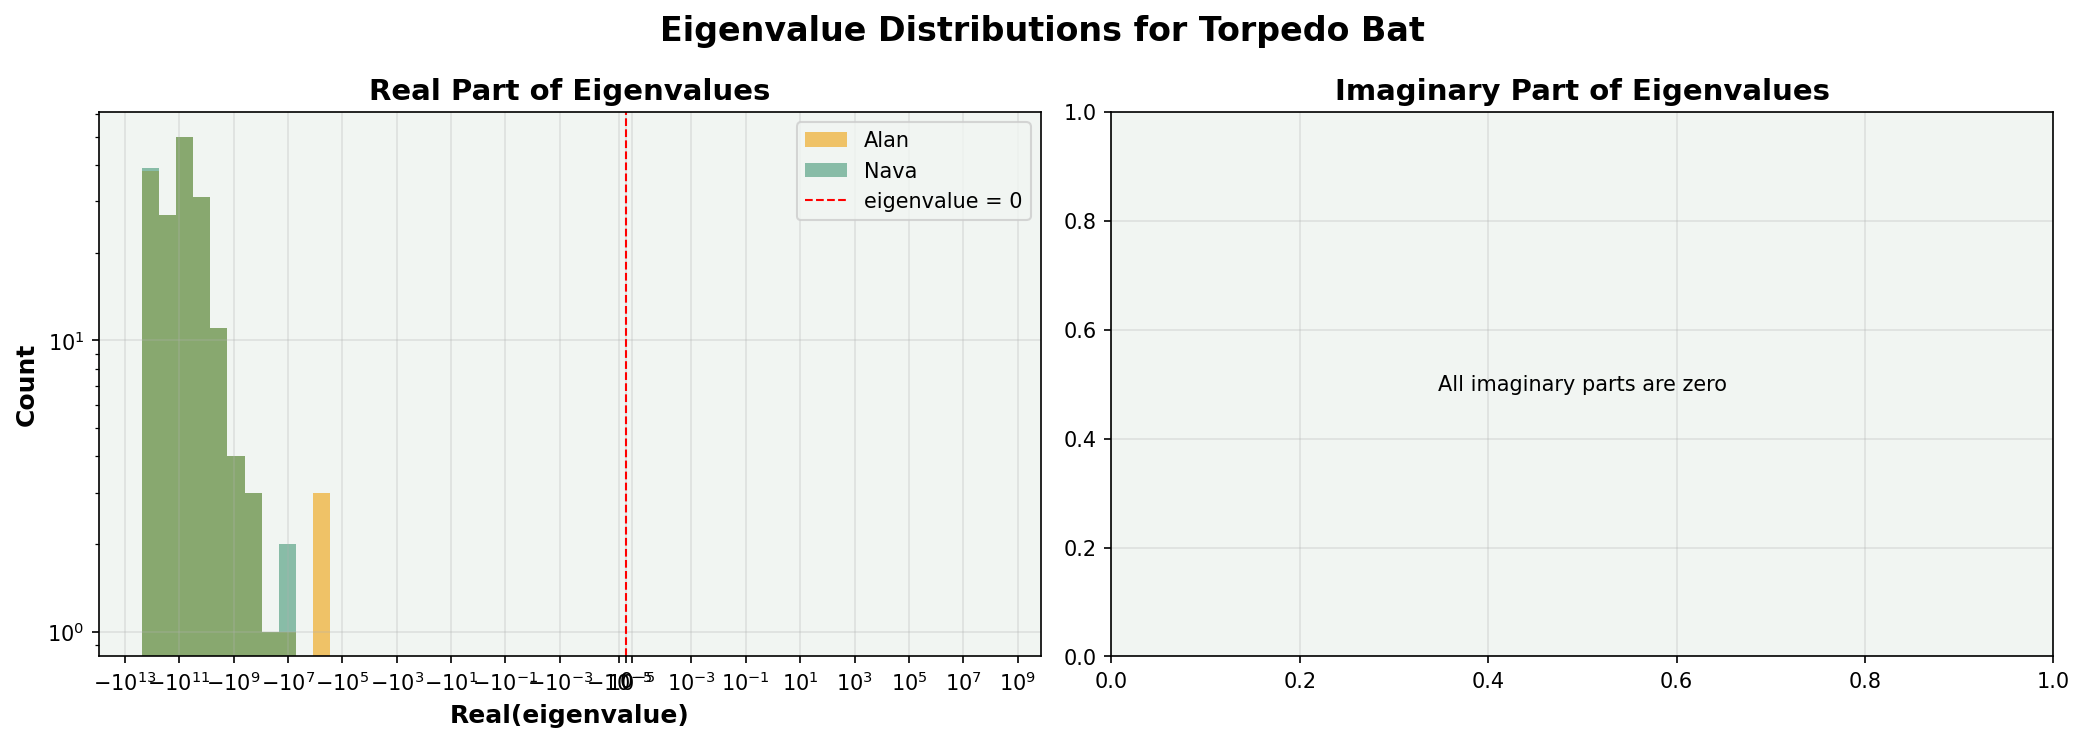

In [52]:
# Compute eigenvalues for both matrices
evals_alan = np.linalg.eig(H_alanT)[0]
evals_nava = np.linalg.eig(H_navaT)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Real part histogram ---
real_alan = evals_alan.real
real_nava = evals_nava.real
real_alan_nz = real_alan[real_alan != 0]
real_nava_nz = real_nava[real_nava != 0]

all_real = np.concatenate([real_alan_nz, real_nava_nz])
r_linthresh = np.min(np.abs(all_real[all_real != 0]))
rbins = symlog_bins([real_alan_nz, real_nava_nz], nbins=50, linthresh=r_linthresh)

axes[0].hist(real_alan_nz, bins=rbins, alpha=0.6, label='Alan', color = colors[0])
axes[0].hist(real_nava_nz, bins=rbins, alpha=0.6, label='Nava', color = colors[1])
axes[0].set_xscale('symlog', linthresh=r_linthresh)
axes[0].set_yscale('log')
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=1, label='eigenvalue = 0')
axes[0].set_xlabel('Real(eigenvalue)')
axes[0].set_ylabel('Count')
axes[0].set_title('Real Part of Eigenvalues')
axes[0].legend()

# --- Imaginary part histogram ---
imag_alan = evals_alan.imag
imag_nava = evals_nava.imag
imag_alan_nz = imag_alan[imag_alan != 0]
imag_nava_nz = imag_nava[imag_nava != 0]

imag_all_nz = np.concatenate([imag_alan_nz, imag_nava_nz])
if len(imag_all_nz) > 0:
    i_linthresh = np.min(np.abs(imag_all_nz[imag_all_nz != 0]))
    ibins = symlog_bins([imag_all_nz], nbins=50, linthresh=i_linthresh)

    if len(imag_alan_nz) > 0:
        axes[1].hist(imag_alan_nz, bins=ibins, alpha=0.6, label='Alan', color = colors[0])
    else:
        axes[1].hist([],alpha = 0.6, label='Alan (all zero)', color = colors[0])
    if len(imag_nava_nz) > 0:
        axes[1].hist(imag_nava_nz, bins=ibins, alpha=0.6, label='Nava', color=colors[1])
    else:
        axes[1].hist([], alpha = 0.6, label='Nava (all zero)', color = colors[1])

    axes[1].set_xscale('symlog', linthresh=i_linthresh)
    axes[1].set_yscale('log')
    axes[1].axvline(x=0, color='r', linestyle='--', linewidth=1, label='eigenvalue = 0')
    axes[1].set_xlabel('Imag(eigenvalue)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Imaginary Part of Eigenvalues')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'All imaginary parts are zero',
                 transform=axes[1].transAxes, ha='center', va='center')
    axes[1].set_title('Imaginary Part of Eigenvalues')
plt.suptitle('Eigenvalue Distributions for Torpedo Bat', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Look at both 

In [53]:
discrepancy_df.rename(columns={'Quandrant': 'Quadrant'}, inplace=True)
discrepancy_dfT['bat'] = 'T'
discrepancy_df['bat'] = 'S'
disc_df = pd.concat([discrepancy_df, discrepancy_dfT], ignore_index=True)
disc_df['N'] = disc_df['bat'].apply(lambda bat: 84 if bat == 'S' else 85)


In [54]:
quad_guide = {'1': ['i', 'i'], '2': ['i', 'j'], '3': ['j', 'i'], '4': ['j', 'j']}
idx_notes = []

for i, row in disc_df.iterrows():
    r = row['Row'] % row['N']
    c = row['Col'] % row['N']
    diff = c-r
    quad = quad_guide[row['Quadrant']]
    if diff > 0:
        sgn = '+'
    elif diff < 0:
        sgn = '-'
    if diff!= 0:
        idx_notes.append(f"H_{{{quad[0]}, {quad[1]} {sgn} {abs(diff)}}}")
    else:
        idx_notes.append(f"H_{{{quad[0]}, {quad[1]}}}")
disc_df['idx_notes'] = idx_notes


In [55]:
disc_df

,Row,Col,Quadrant,Alan Value,Nava Value,Relative Error,bat,N,idx_notes
0,87,3,3,-5.397200e+09,-7.618075e+09,0.411486,T,85,"H_{j, i + 1}"
1,169,85,3,-3.058500e+09,-9.005427e+09,1.944393,T,85,"H_{j, i - 84}"


## **Plots**

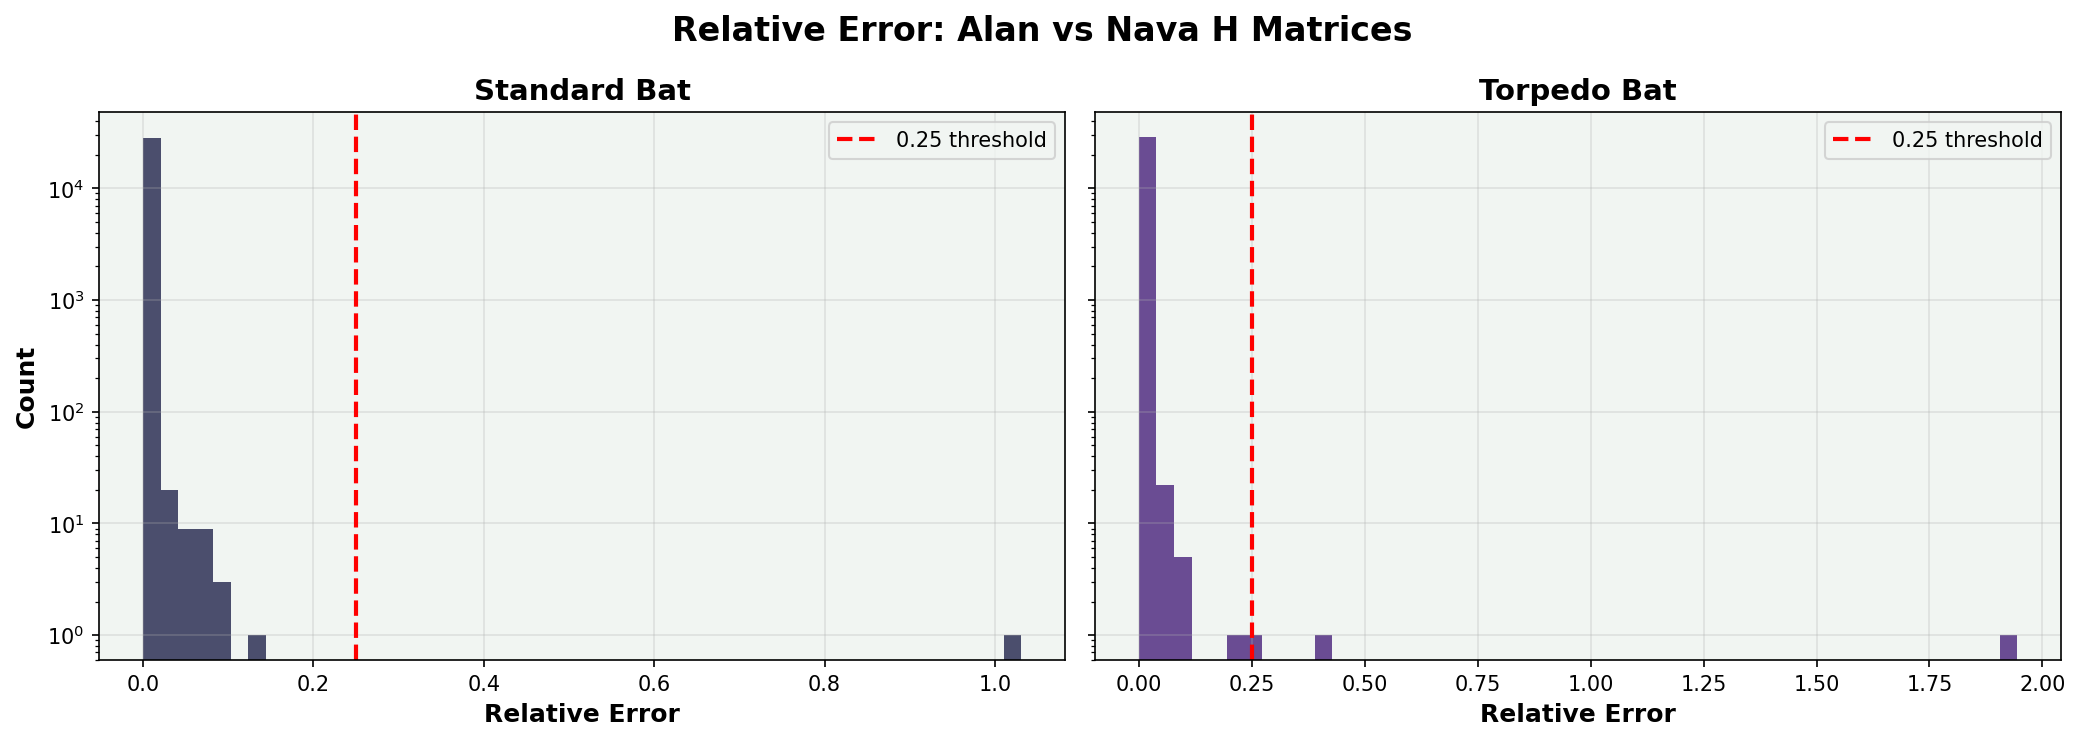

In [56]:
# Relative error side-by-side: Standard vs Torpedo
rel_error_S = np.abs(H_alan - H_nava) / (np.abs(H_alan) + 1e-10)
rel_error_T = np.abs(H_alanT - H_navaT) / (np.abs(H_alanT) + 1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax1.hist(rel_error_S.flatten(), bins=50, color=colors[2])
ax1.axvline(x=0.25, color='red', linestyle='--', label='0.25 threshold')
ax1.set_xlabel('Relative Error')
ax1.set_ylabel('Count')
ax1.set_yscale('log')
ax1.set_title('Standard Bat')
ax1.legend()

ax2.hist(rel_error_T.flatten(), bins=50, color=colors[3])
ax2.axvline(x=0.25, color='red', linestyle='--', label='0.25 threshold')
ax2.set_xlabel('Relative Error')
ax2.set_yscale('log')
ax2.set_title('Torpedo Bat')
ax2.legend()

fig.suptitle('Relative Error: Alan vs Nava H Matrices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('midterm_report/plots/rel_error.pdf')
plt.show()

In [57]:
disc_df.to_csv('midterm_report/err.csv')